# Limb Sounding Validation: Aura MLS

This notebook validates the limb sounding analysis in TAT-C (`collect_limb_observations`, see the [Limb Sounding Observations](../examples/CollectLimb.ipynb) example) against an operational mission: the [Microwave Limb Sounder (MLS)](https://mls.jpl.nasa.gov/) aboard NASA's Aura spacecraft. MLS views forward along the flight direction and scans its antenna upward through the atmosphere roughly every 25 seconds, so it exercises a forward-looking (`scan_azimuth = 0`), upward-scanning configuration.

The comparison uses one full day of MLS data (14 August 2026) and asks four questions, from the most isolated component to the end-to-end result:

1. **Orbit.** Does TAT-C's SGP4 propagation of a public two-line element (TLE) set reproduce Aura's position?
2. **Tangent point geometry.** Given the same time and target altitude as each MLS observation, does TAT-C place the tangent point at the same location?
3. **Vertical scans.** Starting TAT-C scans at the actual MLS scan start times, how closely do the simulated samples match the measured ones in time, altitude, and location?
4. **Daily sampling.** Does a planning-style TAT-C run (as in the example notebook) reproduce the number, latitude distribution, and local solar time of MLS's retrieved profiles?

A companion notebook, [Limb Sounding Validation: TIMED SABER](ValidateLimbSABER.ipynb), repeats the exercise for a side-looking instrument that alternates upward and downward scans.

## Reference Data

MLS products are distributed by the NASA Goddard Earth Sciences Data and Information Services Center (GES DISC). Two version 6 products are used:

* [ML1OA](https://disc.gsfc.nasa.gov/datasets/ML1OA_006/summary) (Level 1B orbit/attitude): for every *major frame* (MAF; one vertical scan) and every *minor frame* (MIF; about 1/6 s) within it, the spacecraft's geodetic position and the GHz radiometer's tangent point geodetic latitude, longitude, and altitude. This is the direct reference for individual sampled points.
* [ML2T](https://disc.gsfc.nasa.gov/datasets/ML2T_006/summary) (Level 2 temperature): the location and time of each retrieved vertical profile (about 3,500 per day). This is the reference for TAT-C's representative `position` per scan.

Downloading requires a free [NASA Earthdata Login](https://urs.earthdata.nasa.gov/) account and the `earthaccess` and `netCDF4` packages (`pip install earthaccess netCDF4`). The Level 1B file is about 260 MB. Files are cached in a local `data` directory and only downloaded once.

In [1]:
from pathlib import Path

import earthaccess

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
L1BOA_FILE = DATA_DIR / "MLS-Aura_L1BOA_v06-03-c01_2026d226.h5"
L2_FILE = DATA_DIR / "MLS-Aura_L2GP-Temperature_v06-03-c01_2026d226.he5"

if not (L1BOA_FILE.exists() and L2_FILE.exists()):
    earthaccess.login()
    granules = [
        granule
        for short_name in ["ML1OA", "ML2T"]
        for granule in earthaccess.search_data(
            short_name=short_name, version="006", temporal=("2026-08-14", "2026-08-14")
        )
    ]
    earthaccess.download(granules, DATA_DIR)

## Setup

Aura is modeled with a TLE whose epoch (14 August 2026, 14:18 UTC) falls within the analysis day, the same TLE used in the example notebook. Helper functions summarize residuals and decompose horizontal offsets into components along and to the right of a reference heading using WGS 84 geodesics.

In [2]:
from datetime import datetime, timedelta, timezone

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import netCDF4 as nc
import numpy as np
import pandas as pd
from pyproj import Geod
from skyfield.api import Distance, wgs84
from skyfield.positionlib import Geocentric

from tatc.analysis import collect_limb_observations
from tatc.utils import rectangular_to_geodetic
from tatc.analysis.limb_sampling import (
    _limb_tangent_point,
    _sample_limb_scan,
)
from tatc.constants import timescale
from tatc.schemas import GeneralPerturbationsOrbit, Satellite
from tatc.utils import pressure_to_altitude

aura = Satellite(
    name="Aura",
    orbit=GeneralPerturbationsOrbit.from_tle(
        [
            "1 28376U 04026A   26226.59599742  .00000334  00000+0  77326-4 0  9994",
            "2 28376  98.3460 183.5488 0001688  86.3454 273.7940 14.61403667174741",
        ]
    ),
)
orbit = aura.orbit.to_gp_orbit()

GEOD = Geod(ellps="WGS84")
DAY0 = datetime(2026, 8, 14, tzinfo=timezone.utc)
TAI93 = datetime(1993, 1, 1, tzinfo=timezone.utc)


def summarize(x):
    """Summary statistics of a residual sample."""
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return pd.Series(
        {
            "n": x.size,
            "mean": x.mean(),
            "std": x.std(),
            "median": np.median(x),
            "p95 |x|": np.percentile(np.abs(x), 95),
            "max |x|": np.abs(x).max(),
        }
    )


def along_right(lon_ref, lat_ref, lon, lat, heading):
    """Offset (km) from reference points, along and to the right of a heading (deg)."""
    azimuth, _, distance = GEOD.inv(lon_ref, lat_ref, lon, lat)
    relative = np.radians(np.asarray(azimuth) - heading)
    return distance * np.cos(relative) / 1e3, distance * np.sin(relative) / 1e3


def binned_median(x, y, edges):
    """Median of y within bins of x."""
    centers = (edges[1:] + edges[:-1]) / 2
    medians = [
        np.median(y[(x >= lo) & (x < hi)]) if np.any((x >= lo) & (x < hi)) else np.nan
        for lo, hi in zip(edges[:-1], edges[1:])
    ]
    return centers, np.array(medians)


BLUE, ORANGE, AQUA, GRAY, INK = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984", "#0b0b0b"
plt.rcParams.update(
    {
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": "#e6e5e0",
        "grid.linewidth": 0.6,
    }
)

## The MLS Vertical Scan

Each MLS major frame lasts about 24.6 s (240 per orbit). The GHz radiometer reports 125 minor frames per major frame; the remainder are used for retrace and calibration. Times are given as seconds since 1 January 1993 in International Atomic Time (TAI), so they are converted to UTC using the offset implied by the file's own UTC time strings.

Aura also performed a spacecraft attitude maneuver on this day: for about 20 minutes, MLS's reported line-of-sight offset from the orbit plane (`OrbY`) reached hundreds of kilometers, and no Level 2 profiles were produced. Those major frames are excluded from the geometry comparisons below.

In [3]:
l1 = nc.Dataset(L1BOA_FILE)
l1.set_auto_mask(False)
N_GHZ = 125

maf_tai = l1["MAFStartTimeTAI"][:]
maf_utc = [
    datetime.strptime(s, "%Y-%m-%dT%H:%M:%S.%fZ").replace(tzinfo=timezone.utc)
    for s in l1["MAFStartTimeUTC"][:]
]
tai_offset = np.median(maf_tai - [(t - TAI93).total_seconds() for t in maf_utc])


def tai_to_utc(tai):
    return TAI93 + timedelta(seconds=float(tai) - tai_offset)


mif_tai = l1["sc/MIF_TAI"][:]
tp_lat, tp_lon, tp_alt = (l1["GHz/" + v][:].astype(float) for v in ["GeodLat", "Lon", "GeodAlt"])
sc_lat, sc_lon, sc_alt = (l1["sc/" + v][:].astype(float) for v in ["GeodLat", "Lon", "GeodAlt"])
orb_y = l1["GHz/OrbY"][:].astype(float)
sc_heading = GEOD.inv(sc_lon[:, 0], sc_lat[:, 0], sc_lon[:, 1], sc_lat[:, 1])[0]

valid = (np.abs(tp_lat) <= 90) & (tp_alt > -10e3) & (tp_alt < 200e3)
nominal = np.all(np.abs(orb_y[:, :N_GHZ]) < 20e3, axis=1)
in_day = np.array([DAY0 <= t < DAY0 + timedelta(days=1) for t in maf_utc])

# median scan profile: altitude vs. time since the start of the major frame
mif_elapsed = mif_tai[:, :N_GHZ] - maf_tai[:, np.newaxis]
alt_median = np.nanmedian(np.where(valid, tp_alt, np.nan)[nominal, :N_GHZ], axis=0)
elapsed_median = np.median(mif_elapsed[nominal], axis=0)
top = int(np.nanargmax(alt_median))

pd.Series(
    {
        "major frame period (s)": np.median(np.diff(maf_tai)),
        "minor frame period (s)": np.median(np.diff(mif_tai[:, :N_GHZ], axis=1)),
        "scan bottom (km)": alt_median[0] / 1e3,
        "scan top (km)": alt_median[top] / 1e3,
        "upward sweep duration (s)": elapsed_median[top],
        "major frames on 14 Aug": in_day.sum(),
        "off-nominal major frames": (~nominal).sum(),
        "off-nominal start (UTC)": maf_utc[np.nonzero(~nominal)[0][0]].strftime("%H:%M:%S"),
        "off-nominal end (UTC)": maf_utc[np.nonzero(~nominal)[0][-1]].strftime("%H:%M:%S"),
        "max off-nominal OrbY (km)": np.abs(orb_y).max() / 1e3,
    }
).to_frame("MLS")

,MLS
major frame period (s),24.644775
minor frame period (s),0.167025
scan bottom (km),1.272713
scan top (km),92.468793
upward sweep duration (s),20.543991
major frames on 14 Aug,3504
off-nominal major frames,51
off-nominal start (UTC),04:45:48
off-nominal end (UTC),05:06:20
max off-nominal OrbY (km),422.948062


## Test 1: Orbit

TAT-C's propagated position is compared with the spacecraft geodetic position reported at the first minor frame of every major frame.

In [4]:
t1 = [tai_to_utc(x) for x in mif_tai[:, 0]]
g1 = wgs84.geographic_position_of(orbit.get_orbit_track(t1))
along1, right1 = along_right(
    sc_lon[:, 0], sc_lat[:, 0], g1.longitude.degrees, g1.latitude.degrees, sc_heading
)
test1 = pd.DataFrame(
    {
        "along-track (km)": summarize(along1),
        "cross-track (km)": summarize(right1),
        "altitude (km)": summarize((g1.elevation.m - sc_alt[:, 0]) / 1e3),
    }
).T
test1.round(3)

,n,mean,std,median,p95 |x|,max |x|
along-track (km),3518.0,0.046,0.514,-0.013,0.840,0.963
cross-track (km),3518.0,0.001,0.122,-0.004,0.232,0.288
altitude (km),3518.0,0.001,0.107,-0.002,0.210,0.265


## Test 2: Tangent Point Geometry

This test isolates TAT-C's tangent point geometry from scan timing. For every GHz minor frame of every fourth nominal major frame, TAT-C's tangent point routine (`_limb_tangent_point`, which `collect_limb_observations` uses for each sample) is evaluated at the exact MLS time, with a forward view (`scan_azimuth = 0`) and the MLS tangent altitude as the requested elevation. Residuals are reported along track and to the right of the spacecraft heading.

TAT-C defines the tangent point as the point of minimum WGS 84 geodetic altitude along the ray and solves for the viewing angle that places it at the requested elevation.

In [5]:
step = 4
mi, ji = np.nonzero(valid[::step, :N_GHZ] & nominal[::step, np.newaxis])
mi *= step
t2 = [tai_to_utc(mif_tai[m, j]) for m, j in zip(mi, ji)]
ts2 = timescale.from_datetimes(t2)
pv2 = orbit.get_orbit_track(t2)
target = tp_alt[mi, ji]


def geodetic(tp_p):
    g = wgs84.geographic_position_of(Geocentric(Distance(m=tp_p).au, None, ts2))
    return g.latitude.degrees, g.longitude.degrees, g.elevation.m


# TAT-C
tp_p, in_domain = _limb_tangent_point(pv2, 0.0, target)
lat2, lon2, alt2 = geodetic(tp_p)
along2, right2 = along_right(tp_lon[mi, ji], tp_lat[mi, ji], lon2, lat2, sc_heading[mi])

test2 = pd.DataFrame(
    {
        "altitude error (km)": summarize((alt2 - target) / 1e3),
        "along-track (km)": summarize(along2),
        "cross-track (km)": summarize(right2),
        "horizontal (km)": summarize(np.hypot(along2, right2)),
    }
).T
test2.round(3)

,n,mean,std,median,p95 |x|,max |x|
altitude error (km),108375.0,0.000,0.000,0.000,0.000,0.000
along-track (km),108375.0,0.069,0.913,-0.056,1.775,3.110
cross-track (km),108375.0,-1.358,0.812,-1.638,1.915,9.234
horizontal (km),108375.0,1.807,0.282,1.810,2.054,9.235


The residuals are almost entirely latitude-dependent, so they are plotted against tangent point latitude. Northward offsets project the along-track component onto north for both ascending and descending passes.

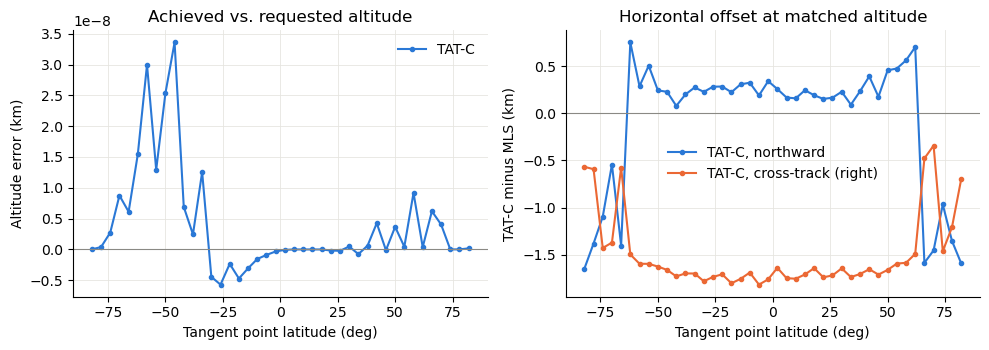

In [6]:
edges = np.arange(-84, 85, 4)
northbound = np.cos(np.radians(sc_heading[mi])) > 0
north = np.where(northbound, 1, -1)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].plot(*binned_median(tp_lat[mi, ji], (alt2 - target) / 1e3, edges), color=BLUE, marker="o", ms=3, label="TAT-C")
axes[0].set(xlabel="Tangent point latitude (deg)", ylabel="Altitude error (km)", title="Achieved vs. requested altitude")
for y, color, label in [
    (north * along2, BLUE, "TAT-C, northward"),
    (right2, ORANGE, "TAT-C, cross-track (right)"),
]:
    axes[1].plot(*binned_median(tp_lat[mi, ji], y, edges), color=color, marker="o", ms=3, label=label)
axes[1].set(xlabel="Tangent point latitude (deg)", ylabel="TAT-C minus MLS (km)", title="Horizontal offset at matched altitude")
for ax in axes:
    ax.axhline(0, color=GRAY, lw=0.8)
    ax.legend(frameon=False)
fig.tight_layout()
plt.show()

The remaining cross-track residual of about 1.6 km is not a TAT-C error: it matches MLS's own reported line-of-sight offset from the orbit plane (`OrbY`) on nominal major frames, i.e. the small real mounting and attitude offset of the MLS boresight that an ideal forward view does not include.

As an independent check of the reference data itself, each MLS tangent point should be the point of minimum geodetic altitude on the straight line from the reported spacecraft position through it. The distance between that point and the reported tangent point (the *tangency defect*) is zero for MLS, confirming its geolocation is internally consistent.

In [7]:
from pyproj import Transformer

TO_ECEF = Transformer.from_crs("EPSG:4979", "EPSG:4978", always_xy=True)


def tangency_defect(sc_lon, sc_lat, sc_alt, tp_lon, tp_lat, tp_alt):
    """Distance (km) from each reported tangent point to the true tangent point
    (minimum geodetic altitude) of the straight line from the spacecraft through it."""
    s = np.array(TO_ECEF.transform(sc_lon, sc_lat, sc_alt))
    p = np.array(TO_ECEF.transform(tp_lon, tp_lat, tp_alt))
    d = (p - s) / np.linalg.norm(p - s, axis=0)

    def minimize(offsets):
        # offset (m) of minimum geodetic altitude among candidates (shape (N, K))
        points = p[:, :, np.newaxis] + d[:, :, np.newaxis] * offsets
        altitudes = rectangular_to_geodetic(points.reshape(3, -1))[2].reshape(offsets.shape)
        return offsets[np.arange(len(offsets)), np.argmin(altitudes, axis=1)]

    coarse = minimize(np.tile(np.linspace(-1000e3, 1000e3, 401), (p.shape[1], 1)))
    return minimize(coarse[:, np.newaxis] + np.linspace(-5e3, 5e3, 201)) / 1e3


sample = slice(None, None, 25)
pd.DataFrame(
    {
        "MLS OrbY, nominal (km)": summarize(orb_y[nominal, :N_GHZ].ravel() / 1e3),
        "MLS tangency defect (km)": summarize(
            tangency_defect(
                sc_lon[mi, ji][sample], sc_lat[mi, ji][sample], sc_alt[mi, ji][sample],
                tp_lon[mi, ji][sample], tp_lat[mi, ji][sample], tp_alt[mi, ji][sample],
            )
        ),
    }
).T.round(3)

,n,mean,std,median,p95 |x|,max |x|
"MLS OrbY, nominal (km)",433375.0,1.714,0.337,1.725,1.804,10.966
MLS tangency defect (km),4335.0,0.000,0.000,0.000,0.000,0.000


## Test 3: Vertical Scans

TAT-C scans are now started at each nominal MLS major frame start time and compared sample by sample with the MLS scan in the same major frame. Two configurations are tested:

* **Example configuration:** the settings of the [example notebook](../examples/CollectLimb.ipynb) (a standard pressure grid from 1000 to 0.01 hPa, roughly 0 to 80 km, swept in 25 s).
* **Matched configuration:** 11 evenly spaced elevations between the bottom and top of the median MLS scan (about 1 to 92 km), swept in the measured upward sweep duration (about 20.5 s).

Per-sample times are taken from `_sample_limb_scan`, the routine `collect_limb_observations` uses for each scan, since the public output reports times only for each scan's start, end, and representative point. The representative `position` and `time` are taken from `collect_limb_observations` itself.

In [8]:
day_idx = np.nonzero(in_day & nominal)[0]
example_elevations = sorted(
    pressure_to_altitude(p * 100) for p in [1000, 300, 100, 30, 10, 3, 1, 0.3, 0.1, 0.03, 0.01]
)
configs = {
    "example": dict(scan_elevations=example_elevations, scan_duration=timedelta(seconds=25)),
    "matched": dict(
        scan_elevations=list(np.linspace(alt_median[0], alt_median[top], 11)),
        scan_duration=timedelta(seconds=float(elapsed_median[top])),
    ),
}


def mls_scan(i):
    """Upward sweep of one MLS major frame: elapsed time, altitude, latitude, unwrapped longitude, altitude order."""
    ok = valid[i, : top + 1]
    alt = tp_alt[i, : top + 1][ok]
    return (
        (mif_tai[i, : top + 1] - maf_tai[i])[ok],
        alt,
        tp_lat[i, : top + 1][ok],
        np.unwrap(tp_lon[i, : top + 1][ok], period=360),
        np.argsort(alt),
    )


rng = np.random.default_rng(0)
subset = np.sort(rng.choice(day_idx, 400, replace=False))
test3, profiles = {}, {}
for name, config in configs.items():
    dh, dt_same_alt, dz_same_time, profile = [], [], [], []
    for i in subset:
        points = _sample_limb_scan(aura, maf_utc[i], 0.0, config["scan_elevations"], config["scan_duration"])
        t, a, la, lo, o = mls_scan(i)
        for p in points:
            elapsed = (p["time"] - maf_utc[i]).total_seconds()
            profile.append((elapsed, p["elevation"] / 1e3))
            if a.min() <= p["elevation"] <= a.max():
                dh.append(
                    GEOD.inv(np.interp(p["elevation"], a[o], lo[o]), np.interp(p["elevation"], a[o], la[o]),
                             p["longitude"], p["latitude"])[2] / 1e3
                )
                dt_same_alt.append(elapsed - np.interp(p["elevation"], a[o], t[o]))
            if t.min() <= elapsed <= t.max():
                dz_same_time.append((p["elevation"] - np.interp(elapsed, t, a)) / 1e3)
    profiles[name] = np.array(profile).reshape(len(subset), -1, 2)

    obs = collect_limb_observations(aura, [maf_utc[i] for i in day_idx], 0.0, **config)
    start_index = {maf_utc[i]: i for i in day_idx}
    position_dh, position_dt = [], []
    for row in obs.itertuples():
        i = start_index[row.start.to_pydatetime()]
        t, a, la, lo, o = mls_scan(i)
        z = row.position.z
        position_dh.append(
            GEOD.inv(np.interp(z, a[o], lo[o]), np.interp(z, a[o], la[o]), row.position.x, row.position.y)[2] / 1e3
        )
        position_dt.append((row.time.to_pydatetime() - maf_utc[i]).total_seconds() - np.interp(z, a[o], t[o]))
    test3[name] = pd.DataFrame(
        {
            "sample time offset at same altitude (s)": summarize(dt_same_alt),
            "sample altitude offset at same time (km)": summarize(dz_same_time),
            "sample horizontal offset at same altitude (km)": summarize(dh),
            "position time offset (s)": summarize(position_dt),
            "position horizontal offset (km)": summarize(position_dh),
        }
    ).T
pd.concat(test3, names=["configuration", "residual"]).round(3)

n    mean  \
configuration residual                                                         
example       sample time offset at same altitude (s)         3977.0  -0.045   
              sample altitude offset at same time (km)        3600.0   0.924   
              sample horizontal offset at same altitude (km)  3977.0  16.859   
              position time offset (s)                        3453.0  -1.826   
              position horizontal offset (km)                 3453.0  13.395   
matched       sample time offset at same altitude (s)         3980.0  -3.785   
              sample altitude offset at same time (km)        4400.0  15.363   
              sample horizontal offset at same altitude (km)  3980.0  26.049   
              position time offset (s)                        3453.0  -5.289   
              position horizontal offset (km)                 3453.0  37.175   

                                                                 std  median  \
configuration residual                                                         
example       sample time offset at same altitude (s)          2.849  -0.720   
              sample altitude offset at same time (km)        10.940   3.682   
              sample horizontal offset at same altitude (km)   9.922  14.294   
              position time offset (s)                         0.770  -1.783   
              position horizontal offset (km)                 12.157  12.064   
matched       sample time offset at same altitude (s)          1.862  -4.316   
              sample altitude offset at same time (km)         9.878  19.064   
              sample horizontal offset at same altitude (km)  12.351  30.187   
              position time offset (s)                         0.643  -5.267   
              position horizontal offset (km)                 12.934  35.820   

                                                              p95 |x|  max |x|  
configuration residual                                                          
example       sample time offset at same altitude (s)           5.479    7.940  
              sample altitude offset at same time (km)         26.268   59.211  
              sample horizontal offset at same altitude (km)   37.776   54.194  
              position time offset (s)                          1.849   11.485  
              position horizontal offset (km)                  13.231  137.599  
matched       sample time offset at same altitude (s)           6.140    6.224  
              sample altitude offset at same time (km)         27.345   86.732  
              sample horizontal offset at same altitude (km)   41.870   43.238  
              position time offset (s)                          5.332   10.445  
              position horizontal offset (km)                  37.041  168.118

The timing differences come from the scan pattern itself. TAT-C models a constant angular-rate scan, but MLS dwells in the troposphere and lower stratosphere (about 2 km/s up to about 25 km) before sweeping faster through the upper stratosphere and mesosphere.

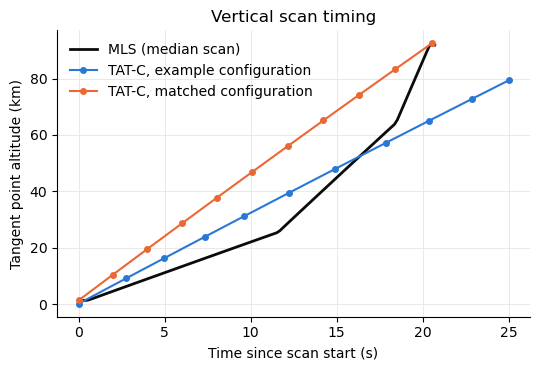

In [9]:
fig, ax = plt.subplots(figsize=(5.5, 3.8))
ax.plot(elapsed_median, alt_median / 1e3, color=INK, lw=2, label="MLS (median scan)")
for name, color, label in [("example", BLUE, "TAT-C, example configuration"), ("matched", ORANGE, "TAT-C, matched configuration")]:
    median_profile = np.median(profiles[name], axis=0)
    ax.plot(median_profile[:, 0], median_profile[:, 1], color=color, marker="o", ms=4, label=label)
ax.set(xlabel="Time since scan start (s)", ylabel="Tangent point altitude (km)", title="Vertical scan timing")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## Test 4: Daily Sampling

Finally, the example notebook's planning-style configuration (scans every 25 s from midnight, independent of the real MLS timeline) is compared with the MLS Level 2 profile locations for the day. Because the two timelines are not synchronized, each MLS profile is matched to the nearest point on TAT-C's (densified) track of representative positions.

In [10]:
l2 = nc.Dataset(L2_FILE)
l2.set_auto_mask(False)
geo = l2["HDFEOS/SWATHS/Temperature/Geolocation Fields"]
l2_time = np.array([tai_to_utc(x) for x in geo["Time"][:]])
l2_lat, l2_lon, l2_lst = (geo[v][:].astype(float) for v in ["Latitude", "Longitude", "LocalSolarTime"])
keep = (np.abs(l2_lat) <= 90) & np.array([DAY0 <= t < DAY0 + timedelta(days=1) for t in l2_time])
l2_time, l2_lat, l2_lon, l2_lst = l2_time[keep], l2_lat[keep], l2_lon[keep], l2_lst[keep]
l2_s = np.array([(t - DAY0).total_seconds() for t in l2_time])

times = [DAY0 + i * timedelta(seconds=25) for i in range(timedelta(days=1) // timedelta(seconds=25))]
limb_obs = collect_limb_observations(aura, times, 0, example_elevations, timedelta(seconds=25))
obs_s = np.array([(t.to_pydatetime() - DAY0).total_seconds() for t in limb_obs.time])
obs_lat = np.array([p.y for p in limb_obs.position])
obs_lon = np.array([p.x for p in limb_obs.position])

dense_s = np.arange(obs_s[0], obs_s[-1], 1.0)
dense_lat = np.interp(dense_s, obs_s, obs_lat)
dense_lon = (np.interp(dense_s, obs_s, np.unwrap(obs_lon, period=360)) + 180) % 360 - 180
nearest_km, nearest_s = [], []
for s, la, lo in zip(l2_s, l2_lat, l2_lon):
    w = np.abs(dense_s - s) < 120
    dist = GEOD.inv(np.full(w.sum(), lo), np.full(w.sum(), la), dense_lon[w], dense_lat[w])[2] / 1e3
    k = np.argmin(dist)
    nearest_km.append(dist[k])
    nearest_s.append(dense_s[w][k] - s)

obs_lst = (obs_s / 3600 + obs_lon / 15) % 24


def equator_lst(lat, lst, ascending):
    return np.median(lst[(np.abs(lat) < 2) & ascending])


test4 = pd.DataFrame(
    {
        "profiles per day": [len(l2_lat), len(limb_obs)],
        "min latitude (deg)": [l2_lat.min(), obs_lat.min()],
        "max latitude (deg)": [l2_lat.max(), obs_lat.max()],
        "ascending equator LST (h)": [
            equator_lst(l2_lat, l2_lst, np.gradient(l2_lat) > 0),
            equator_lst(obs_lat, obs_lst, np.gradient(obs_lat) > 0),
        ],
        "descending equator LST (h)": [
            equator_lst(l2_lat, l2_lst, np.gradient(l2_lat) < 0),
            equator_lst(obs_lat, obs_lst, np.gradient(obs_lat) < 0),
        ],
    },
    index=["MLS Level 2", "TAT-C"],
).T
display(test4.round(2))
pd.DataFrame(
    {"distance to TAT-C track (km)": summarize(nearest_km), "TAT-C time minus L2 time (s)": summarize(nearest_s)}
).T.round(3)

,MLS Level 2,TAT-C
profiles per day,3400.00,3456.00
min latitude (deg),-81.65,-81.71
max latitude (deg),81.65,81.70
ascending equator LST (h),14.71,14.70
descending equator LST (h),2.70,2.70


,n,mean,std,median,p95 |x|,max |x|
distance to TAT-C track (km),3400.0,4.764,3.079,4.428,9.027,126.822
TAT-C time minus L2 time (s),3400.0,11.817,0.660,11.836,12.772,13.881


MLS Level 2 profiles lie a few kilometers from TAT-C's track (about the size of the residuals in Test 2 plus the spacing between profiles), but are time-tagged about 12 s before TAT-C (and the MLS Level 1 tangent point at the same altitude) passes the same location. This offset is a convention of the Level 2 time tag rather than a geometric difference, and should be accounted for when comparing by time.

The latitude distribution of profiles per day agrees closely, including the concentration near the turning latitudes of about ±82 deg.

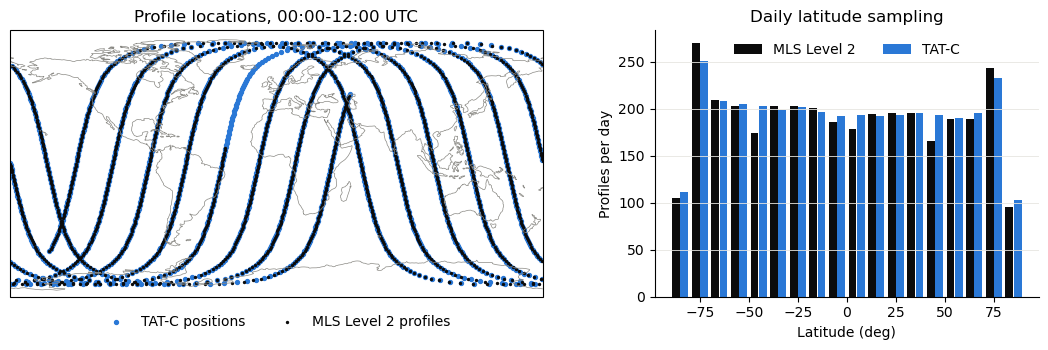

In [11]:
fig, axes = plt.subplots(
    1, 2, figsize=(11, 3.6), gridspec_kw={"width_ratios": [1.6, 1]},
)
axes[0].remove()
ax_map = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
half = obs_s < 12 * 3600
ax_map.scatter(obs_lon[half], obs_lat[half], s=8, color=BLUE, label="TAT-C positions", transform=ccrs.PlateCarree())
ax_map.scatter(l2_lon[l2_s < 12 * 3600], l2_lat[l2_s < 12 * 3600], s=2, color=INK, label="MLS Level 2 profiles", transform=ccrs.PlateCarree())
ax_map.coastlines(color=GRAY, linewidth=0.5)
ax_map.set_global()
ax_map.set_title("Profile locations, 00:00-12:00 UTC")
ax_map.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=2)
bins = np.arange(-90, 91, 10)
centers = (bins[1:] + bins[:-1]) / 2
axes[1].bar(centers - 2.1, np.histogram(l2_lat, bins)[0], width=4, color=INK, label="MLS Level 2")
axes[1].bar(centers + 2.1, np.histogram(obs_lat, bins)[0], width=4, color=BLUE, label="TAT-C")
axes[1].set(xlabel="Latitude (deg)", ylabel="Profiles per day", title="Daily latitude sampling")
axes[1].grid(axis="x", visible=False)
axes[1].legend(frameon=False, loc="upper center", ncol=2)
fig.tight_layout()
plt.show()

## Summary

| Test | Result |
| --- | --- |
| 1. Orbit (TLE vs. MLS spacecraft position) | 0.8 km along track (95th percentile), under 1 km maximum |
| 2. Tangent point at matched time and altitude | Altitude exact; 1.8 km horizontal (median), of which 1.6 km is MLS's real boresight offset from the orbit plane |
| 3. Scan samples (example configuration) | 5.5 s (95th percentile) timing difference at the same altitude; 14 km horizontal (median) |
| 3. Representative position (example configuration) | 1.8 s early and 12 km away (median) |
| 4. Daily sampling vs. Level 2 profiles | Latitude range within 0.06 deg; equator local solar time within 0.01 h; profiles 4.4 km (median) from TAT-C's track |

**Tangent point geometry.** TAT-C reproduces MLS tangent points to about 2 km at the same time and altitude. The tangent point is the point of minimum WGS 84 geodetic altitude along the ray, and the viewing angle is solved so that it reaches the requested geodetic altitude, so tangent points are placed at exactly the requested altitude. MLS's own geolocation is exactly consistent with straight-line (unrefracted) tangency, matching TAT-C's assumption that refraction is not modeled.

**Scan timing.** The main remaining difference is the scan model. TAT-C assumes a constant angular-rate scan, while MLS dwells in the lower atmosphere and then sweeps quickly through the upper atmosphere. Sample times therefore differ by several seconds, which moves tangent points by tens of kilometers along track. Matching the scan's start, end, and duration to MLS does not help, because a constant-rate scan between those endpoints passes through the lower atmosphere too quickly.

**Modeling MLS with TAT-C.** A scan period of 24.64 s (240 scans per orbit) reproduces MLS's 3,504 scans per day; the example's 25 s period gives 3,456. MLS produced 3,400 Level 2 profiles on this day, fewer because of the attitude maneuver. MLS Level 2 time tags lead the tangent point's passage by about 12 s, a convention to account for when comparing by time.

**Limitations.** This validation covers a single day of a forward-looking, upward-scanning instrument. See [Limb Sounding Validation: TIMED SABER](ValidateLimbSABER.ipynb) for a side-looking instrument with both scan directions.